In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
REPO_ROOT = Path.home() / "EASM"
PROCESSED_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
uwnd_file = PROCESSED_DIR / "uwnd_z850_jja_1982_2025.nc"
out_nc = OUTPUT_DIR / "u850_anom_node_composites.nc"
out_fig = OUTPUT_DIR / "u850_anom_node_composites_sig2.png"

uwnd_varname = "uwnd"
extent = [0, 240, -10, 60]
nodes_all = np.arange(1, 10)

In [4]:
# =========================================================
# 1) SOM daily assignments
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")

In [5]:
# =========================================================
# 2) UWND data
# =========================================================
ds = xr.open_dataset(uwnd_file)
uwnd = ds[uwnd_varname]

rename_dict = {}
if "latitude" in uwnd.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in uwnd.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    uwnd = uwnd.rename(rename_dict)

uwnd = uwnd.squeeze(drop=True)
uwnd = uwnd.assign_coords(time=pd.to_datetime(uwnd["time"].values).normalize())
uwnd = uwnd.transpose("time", "lat", "lon")

if uwnd["lat"].values[0] > uwnd["lat"].values[-1]:
    uwnd = uwnd.sortby("lat")
if uwnd["lon"].values[0] > uwnd["lon"].values[-1]:
    uwnd = uwnd.sortby("lon")

uwnd = uwnd.sel(
    lon=slice(extent[0], extent[1]),
    lat=slice(extent[2], extent[3]),
)

/home/user/miniforge3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# =========================================================
# 3) Daily anomaly
# =========================================================
clim = uwnd.groupby("time.dayofyear").mean("time")
uwnd_anom = uwnd.groupby("time.dayofyear") - clim

In [7]:
# =========================================================
# 4) Common dates
# =========================================================
common_time = np.intersect1d(uwnd_anom["time"].values, df["date"].values)

print("len(uwnd_anom time) =", uwnd_anom.sizes["time"])
print("len(df date)        =", len(df))
print("len(common_time)    =", len(common_time))

if len(common_time) == 0:
    raise ValueError("No common dates were found between the SOM CSV and the uwnd dataset.")

uwnd_sel = uwnd_anom.sel(time=common_time)

node_map = (
    df.set_index("date")["node"]
      .reindex(pd.to_datetime(common_time))
)

valid = ~node_map.isna().to_numpy()
uwnd_sel = uwnd_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(uwnd_sel time) =", uwnd_sel.sizes["time"])
print("len(node_vals)     =", len(node_vals))

if uwnd_sel.sizes["time"] == 0:
    raise ValueError("uwnd_sel has zero time samples after aligning dates.")

len(uwnd_anom time) = 4048
len(df date)        = 4048
len(common_time)    = 4048
len(uwnd_sel time) = 4048
len(node_vals)     = 4048


In [8]:
# =========================================================
# 5) Node coordinate
# =========================================================
uwnd_sel = uwnd_sel.assign_coords(node=("time", node_vals))

In [9]:
# =========================================================
# 6) Node composites / std / n / se
# =========================================================
comp = uwnd_sel.groupby("node").mean("time")
std = uwnd_sel.groupby("node").std("time")
n = uwnd_sel.groupby("node").count("time")

comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

se = std / np.sqrt(n)
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)

xr.Dataset(
    {
        "uwnd_anom_comp": comp,
        "uwnd_anom_std": std,
        "uwnd_anom_n": n,
        "uwnd_anom_se": se,
        "uwnd_anom_sig2": sig2.astype(np.int8),
        "uwnd_climatology": clim,
    }
).to_netcdf(out_nc)

print(comp)
print(n)



<xarray.DataArray 'uwnd' (node: 9, lat: 29, lon: 97)> Size: 101kB
array([[[-1.69218183e-01, -1.47485256e-01, -7.90169239e-02, ...,
         -3.90009731e-01, -3.72362971e-01, -3.86166453e-01],
        [-1.94229394e-01, -1.39229387e-01, -4.58797887e-02, ...,
         -2.91394919e-01, -2.15980083e-01, -1.96724802e-01],
        [-1.54735267e-01, -1.13579921e-01, -7.70506561e-02, ...,
         -2.63070285e-01, -1.75861716e-01, -1.26609579e-01],
        ...,
        [ 4.43384051e-01,  5.58444262e-01,  6.57498002e-01, ...,
          2.97282457e-01,  4.76922512e-01,  6.40548289e-01],
        [ 1.54094800e-01,  2.60677814e-01,  3.65449756e-01, ...,
          4.50386196e-01,  5.65103054e-01,  6.46367192e-01],
        [-1.17983095e-01, -7.66974390e-02, -2.02128422e-02, ...,
          5.06596327e-01,  4.87537891e-01,  4.33377713e-01]],

       [[-3.12728554e-01, -5.25931537e-01, -6.02261662e-01, ...,
          7.51930416e-01,  8.00126314e-01,  8.45486403e-01],
        [-1.45944953e-01, -2.66398519

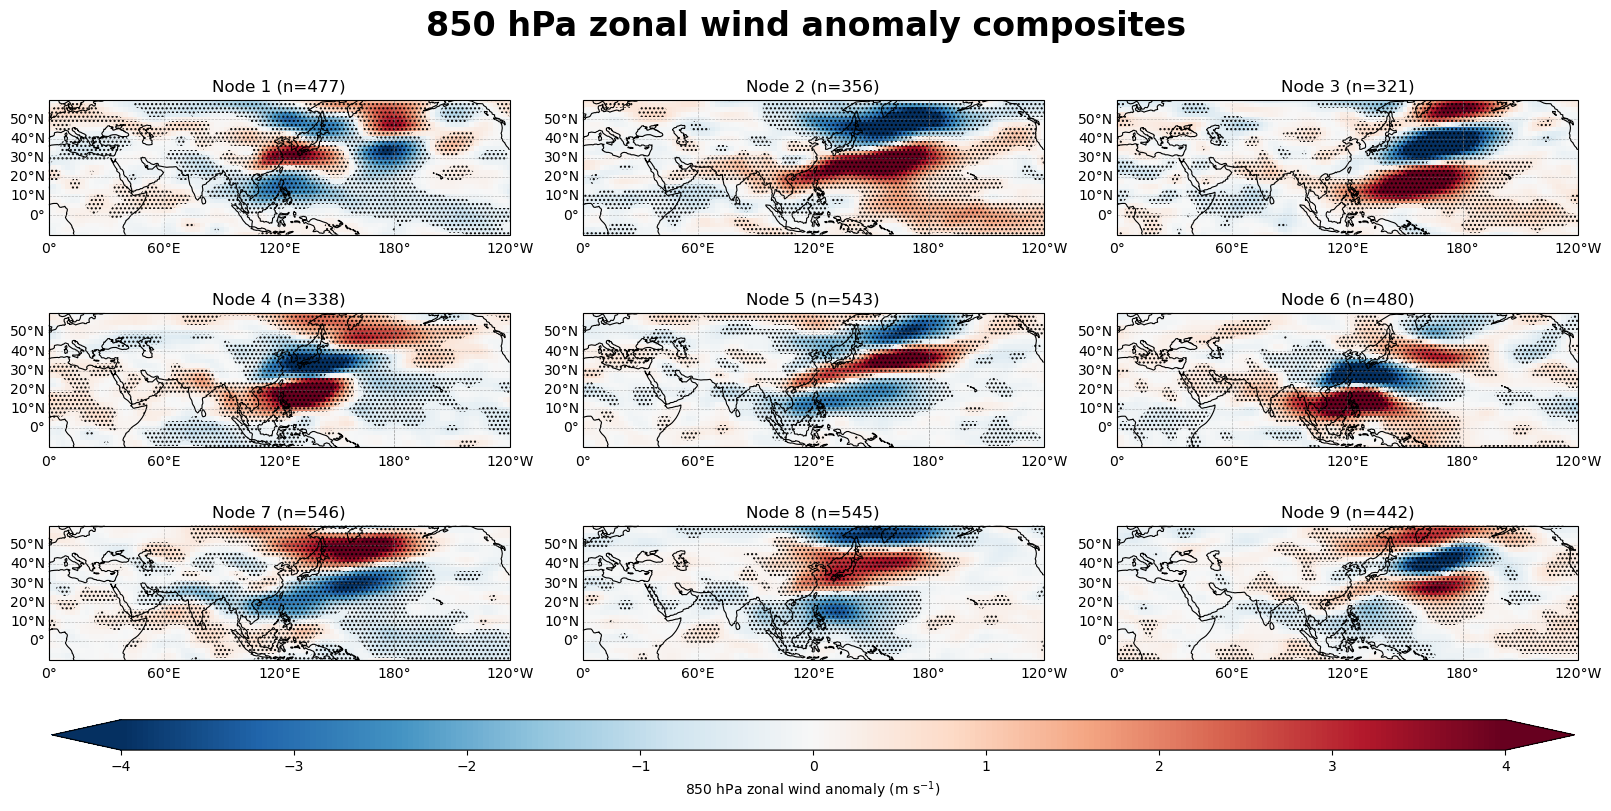

In [ ]:
# =========================================================
# 7) Plot
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3, figsize=(16, 8), layout="constrained", subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)
    node_n = (
        int(np.nanmax(n.sel(node=i).values))
        if np.isfinite(n.sel(node=i).values).any()
        else 0
    )

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            cmap="RdBu_r",
            vmin=-4,
            vmax=4,
            extend="both",
        )

        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"Node {i} (n={node_n})")

if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        aspect=50,
        extend="both",
    )
    cbar.set_label("850 hPa zonal wind anomaly (m s$^{-1}$)")

fig.suptitle("850 hPa zonal wind anomaly composites", fontsize=24, fontweight="bold")

plt.savefig(out_fig, dpi=144, bbox_inches="tight")
plt.show()
